# 04 · Perceptron on Real Datasets (binary classification)
Same 4 functions, from scratch · NumPy for the model · matplotlib for graphs · Runs on Google Colab

| # | Dataset | Task | Features |
|---|---|---|---|
| 1 | Iris | Setosa vs others | 2 |
| 2 | Iris | Versicolor vs virginica | 2 |
| 3 | Banknote | Fake vs real note | 4 |
| 4 | Breast cancer | Malignant vs benign | 30 |

## The 4 functions + train (same logic as before)

| Function | Formula |
|---|---|
| `step(s)` | $1$ if $s \ge 0$ else $0$ |
| `forward_pass(x, w)` | $s = x \cdot w$, then $\hat{y} = \text{step}(s)$ |
| `compute_error(y, y_hat)` | $y - \hat{y}$ |
| `backward_pass(w, x, error, lr)` | $w + \eta \cdot \text{error} \cdot x$ |

Threshold is $w_0$ on input $x_0 = -1$. With hundreds of rows, `train` prints **one line per epoch**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def add_x0(X):
    return np.hstack([-np.ones((len(X), 1)), X])                  # x0 = -1, so w0 is the threshold

def step(s):
    return 1 if s >= 0 else 0

def forward_pass(x, w):
    s = x @ w
    return step(s), s

def compute_error(y, y_hat):
    return y - y_hat

def backward_pass(w, x, error, lr):
    return w + lr * error * x


def train(X, y, w, lr, epochs):
    history, mistakes_per_epoch = [w], []
    for epoch in range(1, epochs + 1):
        mistakes = 0
        for x, target in zip(X, y):
            y_hat, s = forward_pass(x, w)
            error = compute_error(target, y_hat)
            w = backward_pass(w, x, error, lr)
            mistakes += int(error != 0)
        history.append(w)
        mistakes_per_epoch.append(mistakes)
        w_txt = f" | w = {np.round(w, 3)}" if len(w) <= 5 else ""
        print(f"Epoch {epoch:3d} | mistakes {mistakes:4d}/{len(y)} | accuracy {100 * (1 - mistakes / len(y)):5.1f}%{w_txt}")
        if mistakes == 0:
            print(f"Learned in {epoch} epochs (no mistakes)")
            break
    return w, history, mistakes_per_epoch

## Helpers: load, split, scale, evaluate

In [2]:
import io, contextlib, urllib.request

def load_csv(url, skip_header=0):
    text = urllib.request.urlopen(url).read().decode()
    return np.genfromtxt(io.StringIO(text), delimiter=",", dtype=str, skip_header=skip_header)

def split(X, y, test_ratio=0.2):
    idx = rng.permutation(len(X))
    n_test = int(len(X) * test_ratio)
    test, tr = idx[:n_test], idx[n_test:]
    return X[tr], X[test], y[tr], y[test]

def scale(X_train, X_test):
    mean, std = X_train.mean(axis=0), X_train.std(axis=0)         # train statistics only
    return (X_train - mean) / std, (X_test - mean) / std

def predict(X, w):
    return np.array([forward_pass(x, w)[0] for x in X])

def evaluate(X, y, w, name="test"):
    y_hat = predict(X, w)
    tp = int(((y_hat == 1) & (y == 1)).sum()); tn = int(((y_hat == 0) & (y == 0)).sum())
    fp = int(((y_hat == 1) & (y == 0)).sum()); fn = int(((y_hat == 0) & (y == 1)).sum())
    print(f"{name} accuracy: {(tp + tn)}/{len(y)} = {100 * (tp + tn) / len(y):.1f}%")
    print(f"                predicted 1   predicted 0")
    print(f"   actual 1        {tp:4d}          {fn:4d}")
    print(f"   actual 0        {fp:4d}          {tn:4d}")
    return 100 * (tp + tn) / len(y)

def show_one(x, w, target):
    y_hat, s = forward_pass(x, w)
    calc = " + ".join(f"{xi:.2f}×{wi:.2f}" for xi, wi in zip(x, w))
    print(f"s = {calc} = {s:.3f}  ->  step = {y_hat}  (target {target})")

def train_quiet(X, y, w, lr, epochs):
    with contextlib.redirect_stdout(io.StringIO()):
        return train(X, y, w, lr, epochs)

def count_mistakes(X, y, w):
    return int((predict(X, w) != y).sum())

def plot_mistakes(mistakes, title):
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(range(1, len(mistakes) + 1), mistakes, "o-", ms=3)
    ax.set(xlabel="epoch", ylabel="mistakes", title=title)
    plt.show()

## Plot helper for 2-feature datasets
Decision line: $w_1 x_1 + w_2 x_2 = w_0$

In [3]:
def plot_2d(X, y, w_list, labels, title):
    # X: scaled 2 features (no x0). w_list: weights to draw; last one is solid, the rest faded.
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="green", edgecolors="k", label=labels[1])
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="red", marker="X", edgecolors="k", label=labels[0])
    xs = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
    colors = plt.cm.Blues(np.linspace(0.3, 1, len(w_list)))
    for i, w in enumerate(w_list):
        if abs(w[2]) > 1e-9:
            ax.plot(xs, (w[0] - w[1] * xs) / w[2], color=colors[i], lw=3 if i == len(w_list) - 1 else 1)
    ax.set(xlim=(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5), ylim=(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5),
           xlabel="petal length (scaled)", ylabel="petal width (scaled)", title=title)
    ax.legend()
    plt.show()

---
# 1. Iris: setosa vs others (2 features)
## Load

In [4]:
iris = load_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv", skip_header=1)
features = iris[:, 2:4].astype(float)             # petal_length, petal_width
species = iris[:, 4]

print("Shape:", features.shape)
print("First rows (petal length, petal width, species):")
for f, s in zip(features[:3], species[:3]):
    print("  ", f, s)
print("Count per species:", {str(s): int((species == s).sum()) for s in np.unique(species)})

Shape: (150, 2)
First rows (petal length, petal width, species):
   [1.4 0.2] setosa
   [1.4 0.2] setosa
   [1.3 0.2] setosa
Count per species: {'setosa': 50, 'versicolor': 50, 'virginica': 50}


## Split, scale, random start

In [5]:
y1 = (species == "setosa").astype(int)            # 1 = setosa, 0 = other
Xtr, Xte, ytr, yte = split(features, y1)
Xtr, Xte = scale(Xtr, Xte)
Xtr0, Xte0 = add_x0(Xtr), add_x0(Xte)
print(f"train: {len(ytr)} rows, test: {len(yte)} rows")

w = rng.uniform(-1, 1, 3).round(2)
print("\nStart w =", w)
print("One sample worked out:")
show_one(Xtr0[0], w, ytr[0])

train: 120 rows, test: 30 rows

Start w = [ 0.4  -0.47  0.94]
One sample worked out:
s = -1.00×0.40 + 0.27×-0.47 + 0.12×0.94 = -0.412  ->  step = 0  (target 0)


## Train

In [6]:
w_set, hist_set, mis_set = train(Xtr0, ytr, w, lr=0.1, epochs=50)

Epoch   1 | mistakes    3/120 | accuracy  97.5% | w = [ 0.3   -0.832  0.505]
Epoch   2 | mistakes    0/120 | accuracy 100.0% | w = [ 0.3   -0.832  0.505]
Learned in 2 epochs (no mistakes)


## Test

In [7]:
evaluate(Xte0, yte, w_set)
print("\nSome predictions:")
for x, t in zip(Xte0[:5], yte[:5]):
    show_one(x, w_set, t)

test accuracy: 28/30 = 93.3%
                predicted 1   predicted 0
   actual 1           8             2
   actual 0           0            20

Some predictions:
s = -1.00×0.30 + 0.61×-0.83 + 0.78×0.50 = -0.415  ->  step = 0  (target 0)
s = -1.00×0.30 + -0.13×-0.83 + -0.27×0.50 = -0.328  ->  step = 0  (target 0)
s = -1.00×0.30 + 1.07×-0.83 + 0.25×0.50 = -1.062  ->  step = 0  (target 0)
s = -1.00×0.30 + -1.28×-0.83 + -1.33×0.50 = 0.094  ->  step = 1  (target 1)
s = -1.00×0.30 + 0.67×-0.83 + 0.78×0.50 = -0.463  ->  step = 0  (target 0)


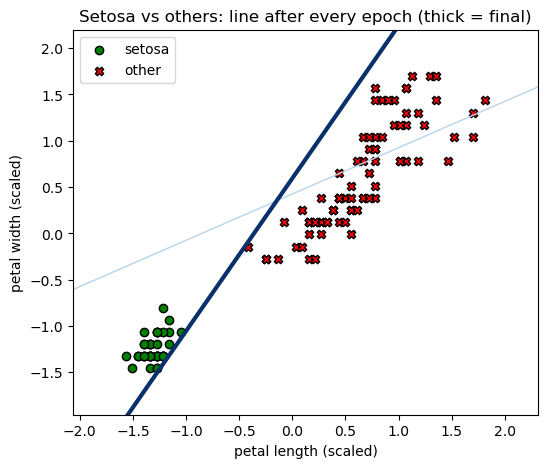

In [8]:
plot_2d(Xtr, ytr, hist_set, ["other", "setosa"], "Setosa vs others: line after every epoch (thick = final)")

Train 100% but test lower: training stops at the **first** line with 0 train mistakes, and that line can sit right next to the setosa points.

---
# 2. Iris: versicolor vs virginica (not perfectly separable)

In [9]:
mask = species != "setosa"
features2 = features[mask]
y2 = (species[mask] == "virginica").astype(int)   # 1 = virginica, 0 = versicolor
print("Shape:", features2.shape, "| virginica:", y2.sum(), "| versicolor:", (1 - y2).sum())

Xtr2, Xte2, ytr2, yte2 = split(features2, y2)
Xtr2, Xte2 = scale(Xtr2, Xte2)
Xtr2_0, Xte2_0 = add_x0(Xtr2), add_x0(Xte2)

w = rng.uniform(-1, 1, 3).round(2)
print("Start w =", w)

Shape: (100, 2) | virginica: 50 | versicolor: 50
Start w = [-0.13  0.98  0.78]


In [10]:
w_vv, hist_vv, mis_vv = train(Xtr2_0, ytr2, w, lr=0.1, epochs=50)

Epoch   1 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.944  0.688]
Epoch   2 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.909  0.596]
Epoch   3 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.873  0.505]
Epoch   4 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.813  0.482]
Epoch   5 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.754  0.459]
Epoch   6 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.694  0.436]
Epoch   7 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.635  0.413]
Epoch   8 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.575  0.39 ]
Epoch   9 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.516  0.367]
Epoch  10 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.456  0.344]
Epoch  11 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.397  0.321]
Epoch  12 | mistakes    6/80 | accuracy  92.5% | w = [-0.13   0.337  0.298]
Epoch  13 | mistakes    7/80 | accuracy  91.2% | w = [-0.03   0.28   0.317]
Epoch  14 | 

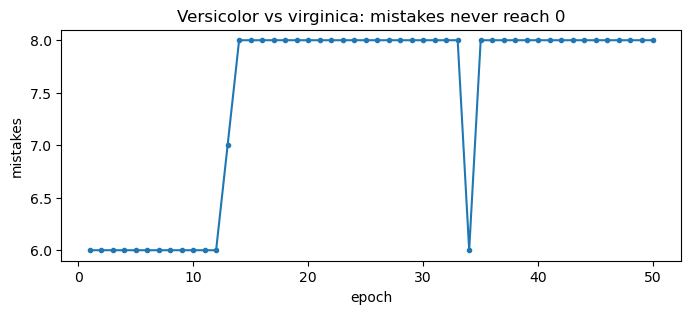

In [11]:
plot_mistakes(mis_vv, "Versicolor vs virginica: mistakes never reach 0")

## Pocket: keep the best weights seen, not the last ones

Last weights  : 7 train mistakes
Pocket weights: 4 train mistakes (after epoch 3)

Last weights:
test accuracy: 20/20 = 100.0%
                predicted 1   predicted 0
   actual 1          11             0
   actual 0           0             9

Pocket weights:
test accuracy: 20/20 = 100.0%
                predicted 1   predicted 0
   actual 1          11             0
   actual 0           0             9


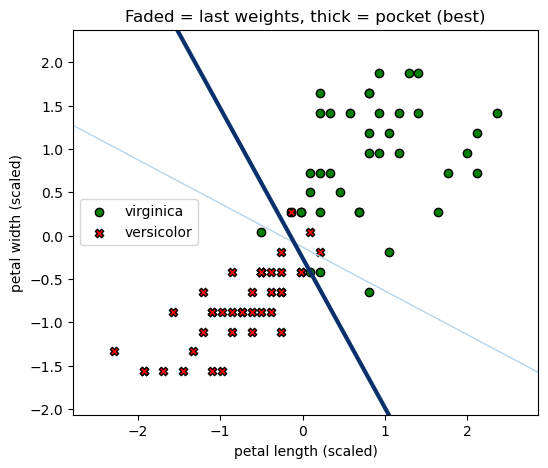

In [12]:
train_errors = [count_mistakes(Xtr2_0, ytr2, w_e) for w_e in hist_vv]
best = int(np.argmin(train_errors))
w_pocket = hist_vv[best]

print(f"Last weights  : {train_errors[-1]} train mistakes")
print(f"Pocket weights: {train_errors[best]} train mistakes (after epoch {best})\n")
print("Last weights:");   evaluate(Xte2_0, yte2, w_vv)
print("\nPocket weights:"); evaluate(Xte2_0, yte2, w_pocket)

plot_2d(Xtr2, ytr2, [w_vv, w_pocket], ["versicolor", "virginica"], "Faded = last weights, thick = pocket (best)")

---
# 3. Banknote authentication: fake vs real (4 features)

In [13]:
bank = load_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt").astype(float)
Xb, yb = bank[:, :4], bank[:, 4].astype(int)      # 1 = fake, 0 = real
bank_features = ["variance", "skewness", "curtosis", "entropy"]

print("Shape:", Xb.shape, "| fake:", yb.sum(), "| real:", (1 - yb).sum())
print("Features:", bank_features)
print("First rows:\n", Xb[:3])

Xtr3, Xte3, ytr3, yte3 = split(Xb, yb)
Xtr3_raw, Xte3_raw = Xtr3, Xte3                   # keep raw copies for the scaling experiment
Xtr3, Xte3 = scale(Xtr3, Xte3)
Xtr3_0, Xte3_0 = add_x0(Xtr3), add_x0(Xte3)

w_start_bank = rng.uniform(-1, 1, 5).round(2)
print("\nStart w =", w_start_bank)
show_one(Xtr3_0[0], w_start_bank, ytr3[0])

Shape: (1372, 4) | fake: 610 | real: 762
Features: ['variance', 'skewness', 'curtosis', 'entropy']
First rows:
 [[ 3.6216   8.6661  -2.8073  -0.44699]
 [ 4.5459   8.1674  -2.4586  -1.4621 ]
 [ 3.866   -2.6383   1.9242   0.10645]]

Start w = [-0.83 -0.65 -0.65  0.65 -0.2 ]
s = -1.00×-0.83 + 1.11×-0.65 + 0.08×-0.65 + 0.12×0.65 + 0.93×-0.20 = -0.054  ->  step = 0  (target 0)


In [14]:
_, hist_bank, mis_bank = train(Xtr3_0, ytr3, w_start_bank, lr=0.1, epochs=30)

Epoch   1 | mistakes   57/1098 | accuracy  94.8% | w = [ 0.27  -0.878 -0.995 -0.623 -0.264]
Epoch   2 | mistakes   29/1098 | accuracy  97.4% | w = [ 0.37  -0.954 -1.079 -0.965 -0.205]
Epoch   3 | mistakes   31/1098 | accuracy  97.2% | w = [ 0.47  -0.965 -1.322 -1.015 -0.042]
Epoch   4 | mistakes   21/1098 | accuracy  98.1% | w = [ 0.57  -1.131 -1.275 -0.973 -0.146]
Epoch   5 | mistakes   26/1098 | accuracy  97.6% | w = [ 0.57  -1.152 -1.373 -0.982 -0.156]
Epoch   6 | mistakes   25/1098 | accuracy  97.7% | w = [ 0.47  -1.199 -1.51  -1.052 -0.214]
Epoch   7 | mistakes   24/1098 | accuracy  97.8% | w = [ 0.67  -1.248 -1.532 -1.131  0.011]
Epoch   8 | mistakes   27/1098 | accuracy  97.5% | w = [ 0.57  -1.387 -1.565 -1.264 -0.187]
Epoch   9 | mistakes   19/1098 | accuracy  98.3% | w = [ 0.67  -1.388 -1.762 -1.122  0.021]
Epoch  10 | mistakes   22/1098 | accuracy  98.0% | w = [ 0.67  -1.543 -1.536 -1.286 -0.066]
Epoch  11 | mistakes   20/1098 | accuracy  98.2% | w = [ 0.67  -1.566 -1.587 -1.

test accuracy: 270/274 = 98.5%
                predicted 1   predicted 0
   actual 1         114             0
   actual 0           4           156


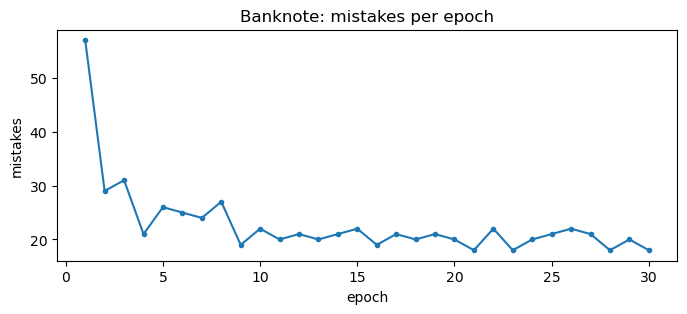

In [15]:
best = int(np.argmin([count_mistakes(Xtr3_0, ytr3, w_e) for w_e in hist_bank]))
w_bank_pocket = hist_bank[best]
evaluate(Xte3_0, yte3, w_bank_pocket)
plot_mistakes(mis_bank, "Banknote: mistakes per epoch")

---
# 4. Breast cancer: malignant vs benign (30 features)

In [16]:
wdbc = load_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data")
Xc = wdbc[:, 2:].astype(float)
yc = (wdbc[:, 1] == "M").astype(int)              # 1 = malignant, 0 = benign
base = ["radius", "texture", "perimeter", "area", "smoothness", "compactness",
        "concavity", "concave points", "symmetry", "fractal dim"]
cancer_features = [f"{p} {b}" for p in ["mean", "se", "worst"] for b in base]

print("Shape:", Xc.shape, "| malignant:", yc.sum(), "| benign:", (1 - yc).sum())
print("First 5 features of row 0:", {f: float(v) for f, v in zip(cancer_features[:5], Xc[0, :5])})

Xtr4, Xte4, ytr4, yte4 = split(Xc, yc)
Xtr4_raw, Xte4_raw = Xtr4, Xte4
Xtr4, Xte4 = scale(Xtr4, Xte4)
Xtr4_0, Xte4_0 = add_x0(Xtr4), add_x0(Xte4)

w_start_cancer = rng.uniform(-1, 1, 31).round(2)

Shape: (569, 30) | malignant: 212 | benign: 357
First 5 features of row 0: {'mean radius': 17.99, 'mean texture': 10.38, 'mean perimeter': 122.8, 'mean area': 1001.0, 'mean smoothness': 0.1184}


In [17]:
_, hist_can, mis_can = train(Xtr4_0, ytr4, w_start_cancer, lr=0.1, epochs=30)

Epoch   1 | mistakes   20/456 | accuracy  95.6%
Epoch   2 | mistakes   12/456 | accuracy  97.4%
Epoch   3 | mistakes    9/456 | accuracy  98.0%
Epoch   4 | mistakes    9/456 | accuracy  98.0%
Epoch   5 | mistakes    9/456 | accuracy  98.0%
Epoch   6 | mistakes   12/456 | accuracy  97.4%
Epoch   7 | mistakes    8/456 | accuracy  98.2%
Epoch   8 | mistakes   12/456 | accuracy  97.4%
Epoch   9 | mistakes   12/456 | accuracy  97.4%
Epoch  10 | mistakes    9/456 | accuracy  98.0%
Epoch  11 | mistakes   10/456 | accuracy  97.8%
Epoch  12 | mistakes    9/456 | accuracy  98.0%
Epoch  13 | mistakes   10/456 | accuracy  97.8%
Epoch  14 | mistakes   12/456 | accuracy  97.4%
Epoch  15 | mistakes   15/456 | accuracy  96.7%
Epoch  16 | mistakes   11/456 | accuracy  97.6%
Epoch  17 | mistakes    7/456 | accuracy  98.5%
Epoch  18 | mistakes    9/456 | accuracy  98.0%
Epoch  19 | mistakes   13/456 | accuracy  97.1%
Epoch  20 | mistakes   13/456 | accuracy  97.1%
Epoch  21 | mistakes   11/456 | accuracy

test accuracy: 108/113 = 95.6%
                predicted 1   predicted 0
   actual 1          34             4
   actual 0           1            74


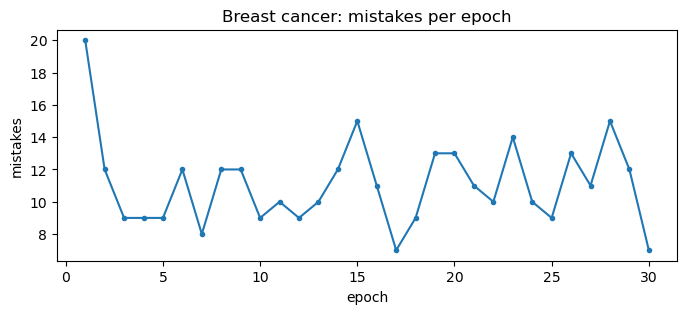

In [18]:
best = int(np.argmin([count_mistakes(Xtr4_0, ytr4, w_e) for w_e in hist_can]))
w_can_pocket = hist_can[best]
evaluate(Xte4_0, yte4, w_can_pocket)
plot_mistakes(mis_can, "Breast cancer: mistakes per epoch")

## Which features matter? (learned weights, threshold $w_0$ excluded)

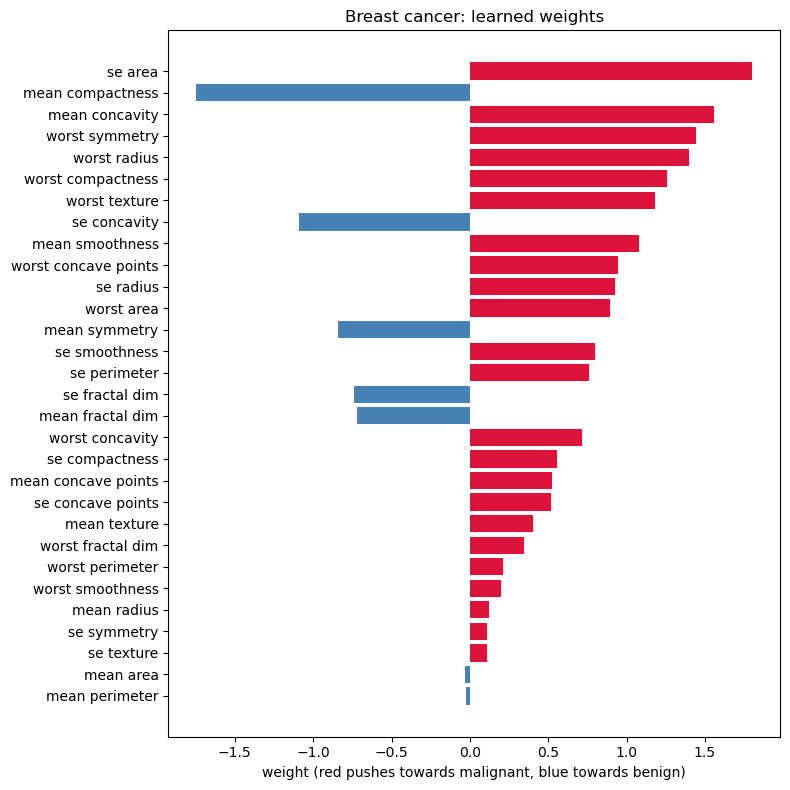

In [19]:
order = np.argsort(np.abs(w_can_pocket[1:]))
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(np.array(cancer_features)[order], w_can_pocket[1:][order],
        color=["crimson" if v > 0 else "steelblue" for v in w_can_pocket[1:][order]])
ax.set(xlabel="weight (red pushes towards malignant, blue towards benign)", title="Breast cancer: learned weights")
plt.tight_layout()
plt.show()

---
# Experiments
## 1. Scaling vs no scaling (same start, same η, 30 epochs, pocket weights)

Banknote       | raw test acc  98.5% | scaled test acc  98.5%
Breast cancer  | raw test acc  92.0% | scaled test acc  95.6%


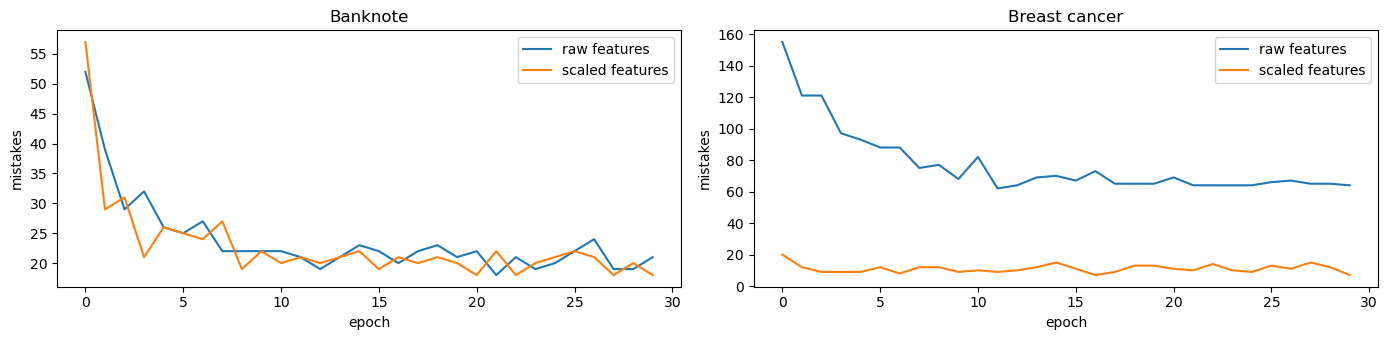

In [20]:
def pocket_run(Xtr_, ytr_, Xte_, yte_, w0, lr, epochs):
    _, hist, mis = train_quiet(add_x0(Xtr_), ytr_, w0, lr, epochs)
    best = min(hist, key=lambda w_e: count_mistakes(add_x0(Xtr_), ytr_, w_e))
    test_acc = 100 * (predict(add_x0(Xte_), best) == yte_).mean()
    return mis, test_acc

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for ax, (name, raw, scaled, w0) in zip(axes, [
        ("Banknote",      (Xtr3_raw, ytr3, Xte3_raw, yte3), (Xtr3, ytr3, Xte3, yte3), w_start_bank),
        ("Breast cancer", (Xtr4_raw, ytr4, Xte4_raw, yte4), (Xtr4, ytr4, Xte4, yte4), w_start_cancer)]):
    mis_raw, acc_raw = pocket_run(*raw, w0, 0.1, 30)
    mis_sc,  acc_sc  = pocket_run(*scaled, w0, 0.1, 30)
    print(f"{name:14s} | raw test acc {acc_raw:5.1f}% | scaled test acc {acc_sc:5.1f}%")
    ax.plot(mis_raw, label="raw features")
    ax.plot(mis_sc, label="scaled features")
    ax.set(title=name, xlabel="epoch", ylabel="mistakes")
    ax.legend()
plt.tight_layout()
plt.show()

## 2. Learning rate (scaled features, pocket weights, test accuracy)

       dataset | η=0.0001 | η=0.001  | η=0.01   | η=0.1    | η=1      | η=10    
--------------------------------------------------------------------------------
   Iris setosa |    23.3% |   100.0% |    96.7% |    96.7% |   100.0% |   100.0%
 Iris vers/vir |    55.0% |    95.0% |   100.0% |   100.0% |   100.0% |   100.0%
      Banknote |    86.5% |    99.3% |   100.0% |    98.5% |    99.3% |    99.3%
 Breast cancer |    77.9% |    97.3% |    96.5% |    93.8% |    95.6% |    94.7%


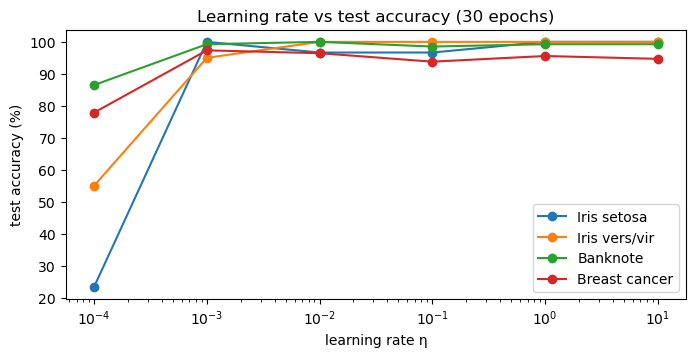

In [21]:
lrs = [0.0001, 0.001, 0.01, 0.1, 1, 10]
datasets = {
    "Iris setosa":  (Xtr, ytr, Xte, yte, 3),
    "Iris vers/vir": (Xtr2, ytr2, Xte2, yte2, 3),
    "Banknote":     (Xtr3, ytr3, Xte3, yte3, 5),
    "Breast cancer": (Xtr4, ytr4, Xte4, yte4, 31),
}
starts = {name: rng.uniform(-1, 1, d[4]).round(2) for name, d in datasets.items()}

print(f"{'dataset':>14} | " + " | ".join(f"η={lr:<6}" for lr in lrs))
print("-" * 80)
results = {}
for name, (a, b, c, d, _) in datasets.items():
    results[name] = [pocket_run(a, b, c, d, starts[name], lr, 30)[1] for lr in lrs]
    print(f"{name:>14} | " + " | ".join(f"{acc:7.1f}%" for acc in results[name]))

fig, ax = plt.subplots(figsize=(8, 3.5))
for name, accs in results.items():
    ax.plot(lrs, accs, "o-", label=name)
ax.set(xscale="log", xlabel="learning rate η", ylabel="test accuracy (%)", title="Learning rate vs test accuracy (30 epochs)")
ax.legend()
plt.show()

## Summary

In [22]:
print(f"{'dataset':>14} | {'features':>8} | {'converged':>9} | {'test acc':>8}")
print("-" * 50)
for name, mis, w_best, Xte_, yte_, nf in [
        ("Iris setosa",   mis_set,  w_set,         Xte0,   yte,  2),
        ("Iris vers/vir", mis_vv,   w_pocket,      Xte2_0, yte2, 2),
        ("Banknote",      mis_bank, w_bank_pocket, Xte3_0, yte3, 4),
        ("Breast cancer", mis_can,  w_can_pocket,  Xte4_0, yte4, 30)]:
    acc = 100 * (predict(Xte_, w_best) == yte_).mean()
    print(f"{name:>14} | {nf:>8} | {'yes' if mis[-1] == 0 else 'no':>9} | {acc:7.1f}%")

       dataset | features | converged | test acc
--------------------------------------------------
   Iris setosa |        2 |       yes |    93.3%
 Iris vers/vir |        2 |        no |   100.0%
      Banknote |        4 |        no |    98.5%
 Breast cancer |       30 |        no |    95.6%
